In [1]:
import os
import time
import sys


import numpy as np
import csv
import torch
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader
from monai.utils import set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import random

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler



In [3]:


DEVICE_TYPE = "cuda:0"


ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

sys.path.append("..")
import AnoDDPM.simplex as simplex

set_determinism(0)


IMAGE_SIZE = 128

EXPERIMENT_NAME = "exp_3_8"
MODELS_DIR = ROOT_DIR+"AnoDiffExperiments/best_models/experiment_3/"

In [4]:

train_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/train.csv")
train_images_path = []

with open(train_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        train_images_path.append(ROOT_DIR+line[0])


train_datalist = train_images_path[:10]



batch_size = 1
num_workers = 4

758it [00:00, 4807.40it/s]


In [5]:

class Get2DSlice(transforms.Transform):
    """
    Fetch the middle slice of a 3D volume.
    Args:
        axis: The axis along which to slice the volume. 0 for axial, 1 for coronal, 2 for sagittal.
        offset : Offset the index by a specified amount (default=0)
    """

    def __init__(
        self,
        axis: int = 0,
        offset: int=0
    ):
        super().__init__()
        self.axis = axis
        self.offset = offset

    def __call__(self, data):
        #print(data.shape)
        if self.axis==0:
            return data[:, data.shape[1]//2+self.offset,:,:]
        elif self.axis==1:
            return data[:, :,data.shape[2]//2+self.offset,:]
        elif self.axis==2:
            return data[:, :, :,data.shape[3]//2+self.offset]


class Get2DSliceWithRandomOffset(transforms.RandomizableTransform):
    """
    Will return the middle slice with a random offset in addition to the specified fixed offset.
    Args:
        axis: The axis along which to slice the volume. 0 for axial, 1 for coronal, 2 for sagittal.
        offset : Offset the index by a specified amount (default=0)
    """

    def __init__(
        self,
        axis: int = 0,
        fixed_offset: int=0
    ):
        super().__init__()
        self.axis = axis
        self.fixed_offset = fixed_offset
        self.rand_offset = 0


    def randomize(self):
        super().randomize(None)
        self.rand_offset = random.randint(-10, 10)

    def __call__(self, data):
        #print(data.shape)
        self.randomize()

        #print(self.rand_offset)
        if self.axis==0:
            return data[:, data.shape[1]//2+self.fixed_offset+self.rand_offset,:,:]
        elif self.axis==1:
            return data[:, :,data.shape[2]//2+self.fixed_offset+self.rand_offset,:]
        elif self.axis==2:
            return data[:, :, :,data.shape[3]//2+self.fixed_offset+self.rand_offset]


class SetBackgroundToZero(transforms.Transform):
    """
    Custom MONAI transform that zeros out voxels with the most frequent intensity value.
    
    Args:
        keys (str or list): Keys of the dictionary to apply the transform to.
        tolerance (int): Optional range around the mode value to also zero.
    """
    def __init__(self, tolerance: int = 0):
        super().__init__()
        self.tolerance = tolerance

    def __call__(self, data):
        
            
        is_tensor = isinstance(data, torch.Tensor)
        data_np = data.cpu().numpy() if is_tensor else data

        # Flatten and compute histogram
        flat = data_np.flatten()
        unique, counts = np.unique(flat, return_counts=True)
        mode_val = unique[np.argmax(counts)]

        # Apply tolerance if specified
        if self.tolerance > 0:
            mask = np.isin(data_np, range(mode_val - self.tolerance, mode_val + self.tolerance + 1))
        else:
            mask = data_np == mode_val

        # Zero out the background
        data_np[mask] = 0

        # Put back in original type
        data = torch.from_numpy(data_np) if is_tensor else data_np

        return data


In [6]:


train_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.NormalizeIntensity(),
        transforms.ScaleIntensity(),
        Get2DSlice(axis=2),
        SetBackgroundToZero(),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
    ]
)
train_ds = CacheDataset(data=train_datalist, transform=train_transforms)
train_loader = DataLoader(
    #collate_fn=pad_list_data_collate: any tensors are centrally padded to match the shape of the biggest tensor in each dimension
    train_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True, collate_fn=pad_list_data_collate
)


Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.12it/s]


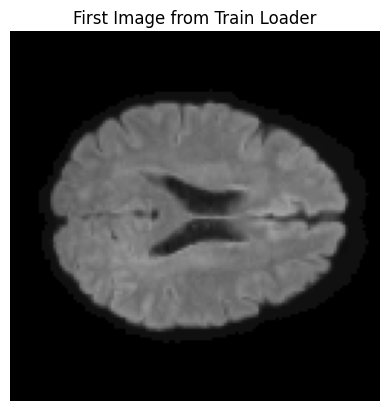

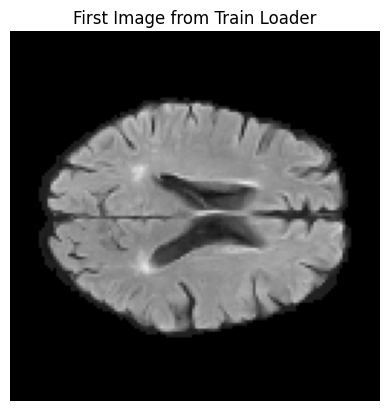

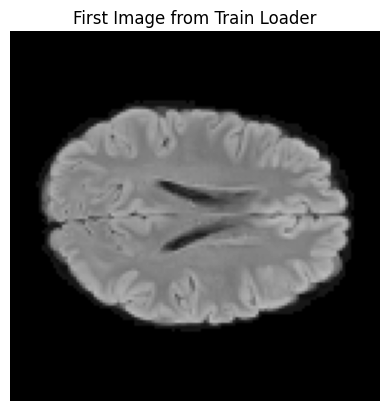

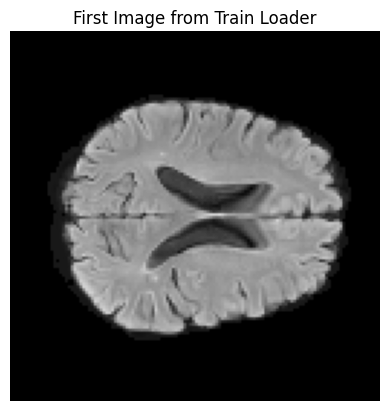

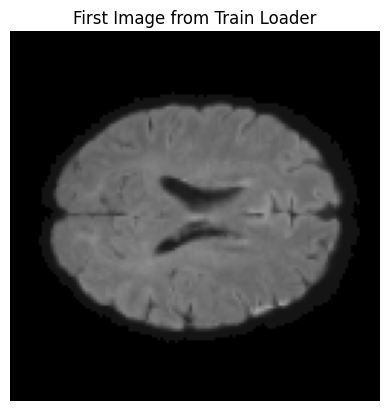

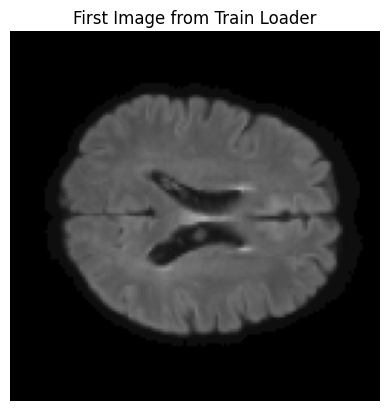

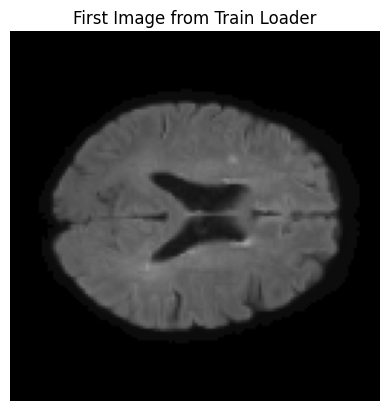

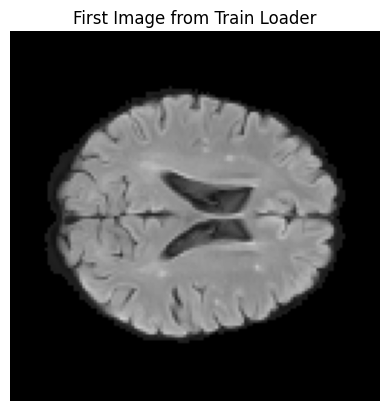

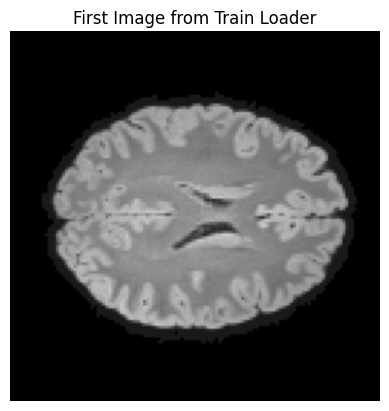

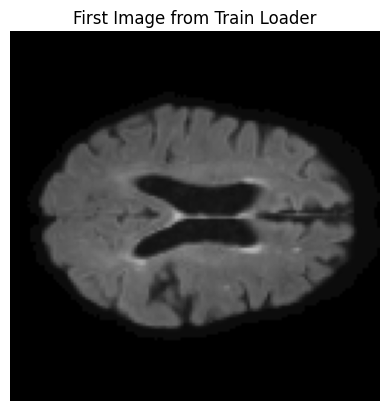

In [7]:
import matplotlib.pyplot as plt

# Get the first batch
for i, batch in enumerate(train_loader):

    # Assuming the data is in the first element of the batch
    image = batch[0][0].numpy()

    # Plot the image
    plt.imshow(image, cmap="gray", vmin=0, vmax=1)
    plt.title("First Image from Train Loader")
    plt.axis("off")
    plt.show()

In [8]:

# ### Opensimplex noise 
# 
# https://code.larus.se/lmas/opensimplex 
# 
# https://pypi.org/project/opensimplex/
# 
# https://github.com/Julian-Wyatt/AnoDDPM/blob/master/simplex.py#L212
# 
# https://openaccess.thecvf.com/content/CVPR2022W/NTIRE/papers/Wyatt_AnoDDPM_Anomaly_Detection_With_Denoising_Diffusion_Probabilistic_Models_Using_Simplex_CVPRW_2022_paper.pdf

# AnoDDPM:
# 
# Instead of using the default simplex noise function, we
# can apply a number of octaves of noise (also known as frac-
# tal noise). This involves combining N frequencies of noise
# together, where the next frequency’s amplitude reduces by
# some decay rate γ. Figure 2b shows that low frequency
# noise cannot be well approximated with a Gaussian distri-
# bution; however, by applying an increasing number of oc-
# taves of noise, the distribution becomes closer to a Gaussian
# distribution. This is paramount for our DDPM model as we
# assume our noising function is sampling from a Gaussian
# distribution. Therefore, unless stated otherwise, we use a
# starting frequency of ν = 2^6 (et pas 2^(-6) comme écrit dans l'article), octave of N = 6 and a de-
# cay of γ = 0.8. Furthermore, when generating the simplex
# noise, we shuffle the seed before every noise calculation,
# and take a slice t from the 3-dimensional noise function,
# as we found that artefacts were introduced when sampling
# from the 2-dimensional noise function
# 
# """
#             Returns a layered fractal noise in 2D\
#         :param shape: Shape of 2D tensor output\
#         :param octaves: Number of levels of fractal noise\
#         :param persistence: float between (0-1) -> Rate at which amplitude of each level decreases\
#         :param frequency: Frequency of initial octave of noise\
#         :return: Fractal noise sample with n lots of 2D images
#         """
# 


simplexObj = simplex.Simplex_CLASS()
simplexObj.newSeed()
# take a slice t from the 3-dimensional noise function as we found that artefacts 
# were introduced when sampling from the 2-dimensional noise function
simplex_noise = simplexObj.rand_3d_octaves(shape=(128,128, 128), octaves=6, persistence=0.8, frequency=64)[12,...]
#plt.figure(figsize=(2, 2))
#plt.imshow(simplex_noise, cmap="gray")
#plt.axis("off")
#plt.show()


# !!! **shuffle the seed before every noise calculation (if timestep = 100: 100 shuffles)**,
# 
# 
# and take a slice t from the 3-dimensional noise function,
# as we found that artefacts were introduced when sampling
# from the 2-dimensional noise function



def generate_simplex_noise(simplexObj, shape):
    """Generate spatially correlated simplex noise."""

    simplexObj.newSeed()

    if len(shape) == 2:
        # take a slice t from the 3-dimensional noise function as we found that artefacts 
        # were introduced when sampling from the 2-dimensional noise function
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[0], shape[1]), octaves=6, persistence=0.8, frequency=64)[12,...]
    elif len(shape) == 3:
        simplex = simplexObj.rand_3d_octaves(shape=shape, octaves=6, persistence=0.8, frequency=64)
    elif len(shape) == 4 and shape[1] == 1: # to make it work with shapes of type (batch_size, 1, height, width)
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[2], shape[3]), octaves=6, persistence=0.8, frequency=64)
        simplex = np.expand_dims(simplex, axis=1)

    return torch.tensor(simplex, dtype=torch.float32)


The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


In [9]:


from monai.utils import StrEnum
from typing import Union

class DDPMPredictionType(StrEnum):
    """
    Set of valid prediction type names for the DDPM scheduler's `prediction_type` argument.

    epsilon: predicting the noise of the diffusion process
    sample: directly predicting the noisy sample
    v_prediction: velocity prediction, see section 2.4 https://imagen.research.google/video/paper.pdf
    """

    EPSILON = "epsilon"
    SAMPLE = "sample"
    V_PREDICTION = "v_prediction"

class SimplexDDPMScheduler(DDPMScheduler):
    def __init__(self, *args, noise_scale=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.noise_scale = noise_scale
        self.simplex_obj = simplex.Simplex_CLASS()
        self.simplex_obj.newSeed()

    #def step(
    #    self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: torch.Generator | None = None
    #) -> tuple[torch.Tensor, torch.Tensor]:
    def step(
        self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: Union[torch.Generator, None] = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Predict the sample at the previous timestep by reversing the SDE. Core function to propagate the diffusion
        process from the learned model outputs (most often the predicted noise).

        Args:
            model_output: direct output from learned diffusion model.
            timestep: current discrete timestep in the diffusion chain.
            sample: current instance of sample being created by diffusion process.
            generator: random number generator.

        Returns:
            pred_prev_sample: Predicted previous sample
        """
        if model_output.shape[1] == sample.shape[1] * 2 and self.variance_type in ["learned", "learned_range"]:
            model_output, predicted_variance = torch.split(model_output, sample.shape[1], dim=1)
        else:
            predicted_variance = None

        # 1. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[timestep - 1] if timestep > 0 else self.one
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        # 2. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (15) from https://arxiv.org/pdf/2006.11239.pdf
        if self.prediction_type == DDPMPredictionType.EPSILON:
            pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
        elif self.prediction_type == DDPMPredictionType.SAMPLE:
            pred_original_sample = model_output
        elif self.prediction_type == DDPMPredictionType.V_PREDICTION:
            pred_original_sample = (alpha_prod_t**0.5) * sample - (beta_prod_t**0.5) * model_output

        # 3. Clip "predicted x_0"
        if self.clip_sample:
            pred_original_sample = torch.clamp(
                pred_original_sample, self.clip_sample_values[0], self.clip_sample_values[1]
            )

        # 4. Compute coefficients for pred_original_sample x_0 and current sample x_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_original_sample_coeff = (alpha_prod_t_prev ** (0.5) * self.betas[timestep]) / beta_prod_t
        current_sample_coeff = self.alphas[timestep] ** (0.5) * beta_prod_t_prev / beta_prod_t

        # 5. Compute predicted previous sample µ_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_prev_sample = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * sample

        # 6. Add noise
        variance: torch.Tensor = torch.tensor(0)
        if timestep > 0:
            self.simplex_obj.newSeed()
            noise = generate_simplex_noise(self.simplex_obj, shape=model_output.size()).to(model_output.device)
            
            """ #TODO
            noise = torch.randn(
                model_output.size(),
                dtype=model_output.dtype,
                layout=model_output.layout,
                generator=generator,
                device=model_output.device,
            )"""
            variance = (self._get_variance(timestep, predicted_variance=predicted_variance) ** 0.5) * noise

        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample, pred_original_sample



In [10]:


device = torch.device(DEVICE_TYPE)
simplexObj = simplex.Simplex_CLASS()


model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(128, 128, 256, 256),
    attention_levels=(False, True, True, True),
    num_head_channels=(0, 128, 128, 256),
)
model.to(device)

num_train_timesteps = 600
scheduler = SimplexDDPMScheduler(num_train_timesteps=num_train_timesteps)

optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)


In [20]:


def train_epoch(epoch, best_val_epoch_loss, best_val_epoch):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=70)
    progress_bar.set_description(f"Epoch {epoch}")
    for step, batch in progress_bar:
        images = batch.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE_TYPE, enabled=True):
            # Generate random noise
            #noise = torch.randn_like(images).to(device)
            noise = generate_simplex_noise(simplexObj, images.shape).to(device)

            # Create timesteps
            timesteps = torch.randint(0, num_train_timesteps, (images.shape[0],), device=images.device).long()

            # Get model prediction
            noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)

            loss = F.mse_loss(noise_pred.float(), noise.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        

        progress_bar.set_postfix({"loss": epoch_loss / (step + 1)})

    epoch_loss_list.append(epoch_loss / (step + 1))
    writer.add_scalar("train_loss", epoch_loss / (step + 1), epoch)

    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_epoch_loss = 0
        for step, batch in enumerate(train_loader):
            images = batch.to(device)
            with torch.no_grad(), autocast(device_type=DEVICE_TYPE, enabled=True):
                noise = generate_simplex_noise(simplexObj, shape=images.shape).to(device)

                timesteps = torch.randint(0, num_train_timesteps, (images.shape[0],), device=images.device).long()
                noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
                val_loss = F.mse_loss(noise_pred.float(), noise.float())

            val_epoch_loss += val_loss.item()

            progress_bar.set_postfix({"val_loss": val_epoch_loss / (step + 1)})

        val_epoch_loss_list.append(val_epoch_loss / (step + 1))
        writer.add_scalar("val_loss", val_epoch_loss / (step + 1), epoch)   # moi

        if val_epoch_loss < best_val_epoch_loss:
            best_val_epoch_loss = val_epoch_loss
            best_val_epoch = epoch + 1
            torch.save(
                model.state_dict(),
                os.path.join(MODELS_DIR, f"{EXPERIMENT_NAME}_best_model.pth"),
            )
            print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current val loss: {val_epoch_loss/(step + 1):.4f}"
                f"\nbest val loss: {best_val_epoch_loss/(step + 1):.4f}"
                f" at epoch: {best_val_epoch}"
            )
            writer.add_scalar("best_val_loss", best_val_epoch_loss/(step + 1), best_val_epoch)
    
    return best_val_epoch_loss, best_val_epoch

In [ ]:
print("STARTING NEW TRAINING")
os.makedirs(ROOT_DIR+f"AnoDiffExperiments/tensorboard/{EXPERIMENT_NAME}", exist_ok=True)
writer = SummaryWriter(ROOT_DIR+f"AnoDiffExperiments/tensorboard/{EXPERIMENT_NAME}")

max_epochs = 20000
val_interval = 4
epoch_loss_list = []
val_epoch_loss_list = []

best_val_epoch_loss = np.inf
best_val_epoch = 0

scaler = GradScaler(DEVICE_TYPE)
total_start = time.time()


for epoch in range(max_epochs):
    best_val_epoch_loss, best_val_epoch = train_epoch(epoch, best_val_epoch_loss, best_val_epoch)

In [9]:
# Load the model weights from MODELS_DIR
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{EXPERIMENT_NAME}_best_model.pth"), map_location=device))
model.eval()

DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler